In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the gridworld environment
grid_size = (4, 4)  # 4x4 grid
states = [(i, j) for i in range(1, 5) for j in range(1, 5)]  # (1,1) to (4,4)

# Rewards based on the grid
rewards = {
    (3, 1): -5,  # Cat penalty
    (3, 3): -5,  # Cat penalty
    (1, 3): 1,   # Treat +1
    (3, 2): 5,   # Treat +2
    (2, 4): 5,   # Ball +5
    (4, 4): 100,  # Owner +20
}
default_reward = 0

# Transition probability of slipping
slip_prob = 0.6
discount_factor = 0.9

# Actions
actions = {
    "up": (-1, 0),
    "down": (1, 0),
    "left": (0, -1),
    "right": (0, 1),
}

# Initialize value function and policy
value_function = {state: 0 for state in states}
policy = {state: None for state in states}

# Value Iteration
def get_next_state(state, action):
    """Get the next state based on action."""
    next_state = (state[0] + action[0], state[1] + action[1])
    if next_state in states:
        return next_state
    return state  # If next state is out of bounds, remain in the same state

def value_iteration(threshold=1e-4, max_iterations=1000):
    for iteration in range(max_iterations):
        delta = 0  # Change in value function
        new_value_function = value_function.copy()

        for state in states:
            if state == (4, 4):  # Terminal state
                new_value_function[state] = rewards.get(state, default_reward)
                continue

            max_value = float("-inf")
            best_action = None

            for action_name, action in actions.items():
                # Calculate expected value
                value = 0

                # Intended move
                next_state = get_next_state(state, action)
                reward = rewards.get(next_state, default_reward)
                value += (1 - slip_prob) * (reward + discount_factor * value_function[next_state])

                # Slip moves (all other actions)
                for slip_action_name, slip_action in actions.items():
                    if slip_action_name != action_name:
                        slip_next_state = get_next_state(state, slip_action)
                        slip_reward = rewards.get(slip_next_state, default_reward)
                        value += (slip_prob / (len(actions) - 1)) * (
                            slip_reward + discount_factor * value_function[slip_next_state]
                        )

                if value > max_value:
                    max_value = value
                    best_action = action_name

            new_value_function[state] = max_value
            policy[state] = best_action
            delta = max(delta, abs(value_function[state] - new_value_function[state]))

        value_function.update(new_value_function)

        if delta < threshold:
            break

    return value_function, policy

# Perform value iteration
optimal_values, optimal_policy = value_iteration()


In [2]:

# Format the results
import pandas as pd

value_df = pd.DataFrame(np.zeros(grid_size), index=range(1, 5), columns=range(1, 5))
policy_df = pd.DataFrame(np.full(grid_size, None), index=range(1, 5), columns=range(1, 5))

for state, value in optimal_values.items():
    value_df.at[state] = value

for state, action in optimal_policy.items():
    policy_df.at[state] = action


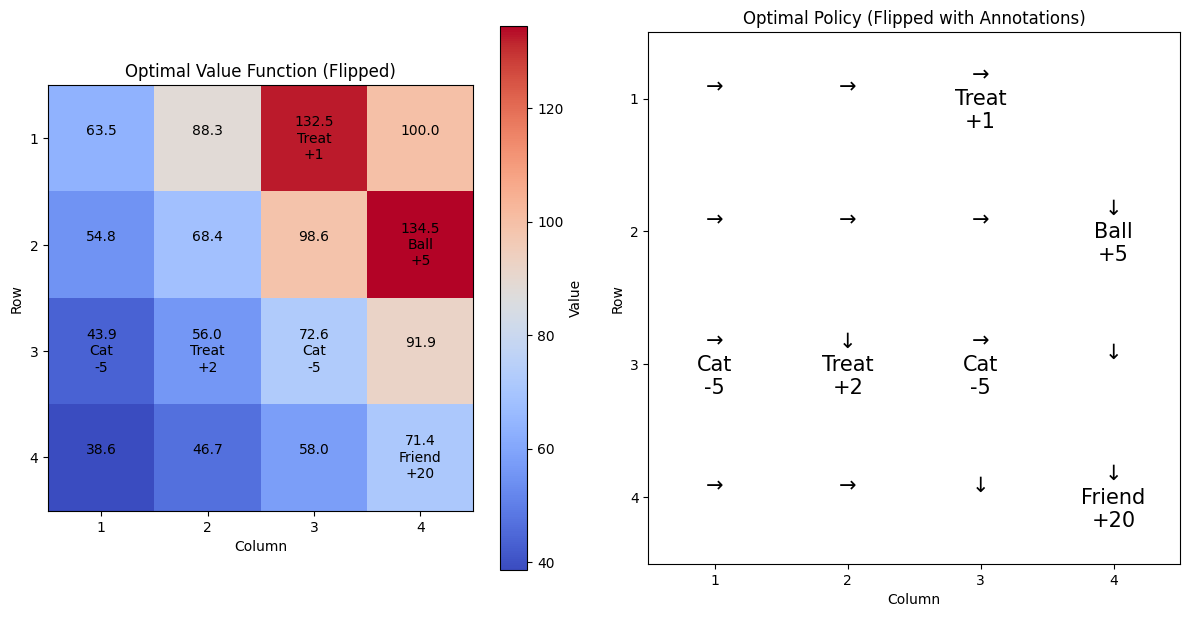

In [5]:
# Mapping actions to arrows
action_arrows = {
    "up": "↑",
    "down": "↓",
    "left": "←",
    "right": "→",
    None: ""  # For terminal states
}

value_array = value_df.to_numpy()
policy_array = policy_df.to_numpy()
# Flip the arrays for the updated view and apply arrows for policy
flipped_value_array = np.flip(value_array, axis=0)
flipped_policy_array = np.flip(policy_array, axis=0)
arrow_policy_array = np.vectorize(lambda x: action_arrows[x])(flipped_policy_array)

# Annotations for treats, cats, ball, and friend
annotations = np.empty_like(flipped_value_array, dtype=object)
annotations.fill("")
annotations[3, 3] = "Friend\n+20"  # Terminal state at (4,4)
annotations[2, 0] = "Cat\n-5"      # Cat at (1,4)
annotations[2, 2] = "Cat\n-5"      # Cat at (2,4)
annotations[0, 2] = "Treat\n+1"    # Treat at (1,3)
annotations[2, 1] = "Treat\n+2"    # Treat at (2,3)
annotations[1, 3] = "Ball\n+5"     # Ball at (1,2)

# Plot the heatmaps with arrows and annotations
plt.figure(figsize=(12, 6))

# Heatmap for optimal value function (flipped)
plt.subplot(1, 2, 1)
plt.title("Optimal Value Function (Flipped)")
plt.imshow(flipped_value_array, cmap="coolwarm", origin="upper", interpolation="none")
for i in range(flipped_value_array.shape[0]):
    for j in range(flipped_value_array.shape[1]):
        plt.text(j, i, f"{flipped_value_array[i, j]:.1f}\n{annotations[i, j]}", 
                 ha="center", va="center", color="black")
plt.colorbar(label="Value")
plt.xticks(range(4), range(1, 5))
plt.yticks(range(4), range(1, 5))
plt.xlabel("Column")
plt.ylabel("Row")

# Heatmap for optimal policy (flipped with arrows)
plt.subplot(1, 2, 2)
plt.title("Optimal Policy (Flipped with Annotations)")
plt.imshow(np.zeros_like(flipped_value_array), cmap="Greys", origin="upper", interpolation="none")
for i in range(arrow_policy_array.shape[0]):
    for j in range(arrow_policy_array.shape[1]):
        plt.text(j, i, f"{arrow_policy_array[i, j]}\n{annotations[i, j]}", 
                 ha="center", va="center", color="black", fontsize=15)
plt.xticks(range(4), range(1, 5))
plt.yticks(range(4), range(1, 5))
plt.xlabel("Column")
plt.ylabel("Row")

plt.tight_layout()
plt.show()
